Importing required libraries

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.integrate import solve_ivp, odeint
from scipy.interpolate import interp1d

Plot style

In [2]:
def set_plot_style():
    plt.rcParams.update({
        "figure.figsize": (16, 7), # Adjusted for potential side-by-side plots
        "axes.grid": False,
        "grid.linestyle": ":",
        "grid.alpha": 0.6,
        "axes.labelsize": 20,  # Increased
        "xtick.labelsize": 18, # Increased
        "ytick.labelsize": 18, # Increased
        "legend.fontsize": 15, # Increased
        "axes.titlesize": 22,  # Increased
        "figure.titlesize": 22, # Increased

        "axes.edgecolor": "black", # Set axis line color to black
        "axes.labelcolor": "black", # Set axis label color to black
        "xtick.color": "black", # Set x-tick color to black
        "ytick.color": "black", # Set y-tick color to black
        "text.color": "black", # Set general text color to black
        "axes.linewidth": 1.5, # Thicker axis lines
        "xtick.major.width": 1.5, # Thicker major x ticks
        "ytick.major.width": 1.5, # Thicker major y ticks
        "font.size": 18, # General font size
    })



Generate Synthetic data

In [3]:
def saramito_model_tauM(tau_M, t, lambda_, tau_0, eta_p, strain_rate_func):
    """
    ODE for Maxwell stress component tau_M:
        (eta_p/G) d tau_M/dt + max(0, (|tau_M| - tau_0)/|tau_M|) tau_M = eta_p * gammadot
    Here lambda_ = eta_p / G is used in the implemented form (same as your original code).
    """
    strain_rate_t = strain_rate_func(t)
    abs_tauM = np.abs(tau_M)
    max_term = max(0, (abs_tauM - tau_0) / abs_tauM) if abs_tauM != 0 else 0
    dtauM_dt = (eta_p * strain_rate_t - max_term * tau_M) / lambda_
    return dtauM_dt


def compute_tauM_and_sigma(t, lambda_, tau_0, eta_p, eta, strain, strain_rate):
    """
    Returns:
      tau_M(t) : Maxwell stress component
      sigma(t) : total stress = eta * gammadot + tau_M
    """
    strain_rate_func = interp1d(t, strain_rate, kind="cubic", fill_value="extrapolate")
    tauM_initial = 0.0

    lambda_safe = max(lambda_, 1e-9)  # avoid division by zero
    tau_M = odeint(
        saramito_model_tauM,
        tauM_initial,
        t,
        args=(lambda_safe, tau_0, eta_p, strain_rate_func),
        mxstep=1000,
    ).flatten()

    sigma = tau_M + eta * strain_rate
    return tau_M, sigma


def generate_steady_cycle(
    amplitude,
    omega,
    lambda_,
    tau_0,
    eta_p,
    eta,
    n_cycles_total=6,
    points_per_cycle=200,
):
    """Simulate many cycles; return only the last cycle (steady state)."""
    period = 2.0 * np.pi / omega
    t_full = np.linspace(
        0, n_cycles_total * period,
        n_cycles_total * points_per_cycle,
        endpoint=False,
    )

    strain = amplitude * np.sin(omega * t_full)
    strain_rate = amplitude * omega * np.cos(omega * t_full)

    tau_M_full, sigma_full = compute_tauM_and_sigma(
        t_full, lambda_, tau_0, eta_p, eta, strain, strain_rate
    )

    start = (n_cycles_total - 1) * points_per_cycle
    end = n_cycles_total * points_per_cycle

    t_cycle = t_full[start:end] - t_full[start]
    return (
        t_cycle,
        strain[start:end],
        strain_rate[start:end],
        tau_M_full[start:end],
        sigma_full[start:end],
    )

Neural network + Learnable model's parameters

In [4]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 50)
        self.fc2 = nn.Linear(50, 50)
        self.fc_sigma = nn.Linear(50, 1)  # outputs scaled total stress (sigma)

        # train-time parameters in scaled space
        self.lambda_raw = nn.Parameter(torch.tensor(0.1))
        self.eta_p_raw  = nn.Parameter(torch.tensor(0.1))
        self.eta_raw    = nn.Parameter(torch.tensor(0.1))
        self.tau_0_raw = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc_sigma(x)

    def get_parameters(self):
        lam   = torch.relu(self.lambda_raw)
        eta_p = torch.relu(self.eta_p_raw)
        eta   = torch.relu(self.eta_raw)
        tau_0 = torch.relu(self.tau_0_raw)
        return lam, eta_p, eta, tau_0


Loss function

In [5]:
def loss_function(
    sigma_pred_scaled,
    sigma_true_scaled,
    lam_scaled,
    tau_0_scaled,
    eta_p_scaled,
    eta_scaled,
    strain_rate_scaled,
    dt_scaled,
    alpha,
):
    # tau_M_pred_scaled is the Maxwell component (scaled)
    tau_M_pred_scaled = sigma_pred_scaled - eta_scaled * strain_rate_scaled
    abs_tauM_scaled = torch.abs(tau_M_pred_scaled)

    max_term_scaled = torch.where(
        abs_tauM_scaled > tau_0_scaled,
        (abs_tauM_scaled - tau_0_scaled) / (abs_tauM_scaled + 1e-9),
        torch.tensor(0.0, dtype=torch.float32, device=abs_tauM_scaled.device),
    )

    dtauM_dt_scaled = (
        (eta_p_scaled * strain_rate_scaled - max_term_scaled * tau_M_pred_scaled)
        / (lam_scaled + 1e-9)
    )

    # integrate to get tau_M_cumsum_scaled
    tau_M_cumsum_scaled = torch.cumsum(dtauM_dt_scaled * dt_scaled, dim=0) + tau_M_pred_scaled[0]

    # reconstruct sigma using integrated tau_M (physics-informed)
    sigma_comp_scaled = eta_scaled * strain_rate_scaled + tau_M_cumsum_scaled

    data_loss = torch.mean((sigma_true_scaled - sigma_pred_scaled) ** 2)
    eq_loss1  = torch.mean((sigma_true_scaled - sigma_comp_scaled) ** 2)
    eq_loss2  = torch.mean((tau_M_cumsum_scaled - tau_M_pred_scaled) ** 2)

    physics_loss = eq_loss1 + eq_loss2
    total_loss = data_loss + alpha * physics_loss
    return total_loss, data_loss, physics_loss

Learning rate adjustment

In [6]:
def warmup_then_cosine_lr(
    epoch,
    total_epochs,
    warmup_epochs=100,
    initial_lr=5e-4,
    max_lr=5e-4,
    min_lr=1e-6,
):
    if epoch < warmup_epochs:
        return initial_lr + (max_lr - initial_lr) * (epoch / float(warmup_epochs))
    progress = (epoch - warmup_epochs) / float(total_epochs - warmup_epochs)
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))

Plot functions

In [7]:
def plot_initial_data(t, strain, strain_rate, tau_M, sigma, omega):
    fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

    axs[0].plot(t, strain, linewidth=2, label=r"Strain $\gamma(t)$")
    axs[0].plot(t, strain_rate, linewidth=2, linestyle="--", alpha=0.8,
                label=r"Strain rate $\dot{\gamma}(t)$")
    axs[0].set_ylabel("Input")
    axs[0].set_title("Input kinematics (steady cycle)")
    axs[0].legend(frameon=False)

    axs[1].plot(t, tau_M, linewidth=2, label=r"Maxwell stress $\tau_M(t)$")
    axs[1].set_ylabel(r"$\tau_M$ (Pa)")
    axs[1].set_title("Maxwell component")
    axs[1].legend(frameon=False)

    axs[2].plot(t, sigma, linewidth=2, label=r"Total stress $\sigma(t)$")
    axs[2].set_xlabel("Time within one cycle (s)")
    axs[2].set_ylabel(r"$\sigma$ (Pa)")
    axs[2].set_title("Total stress")
    axs[2].legend(frameon=False)

    fig.suptitle("Synthetic steady-state LAOS data", y=1.02)
    plt.tight_layout()
    plt.show()

    # Lissajous-Bowditch (total stress)
    plt.figure(figsize=(10, 9))
    plt.plot(strain, sigma, linewidth=2.5, label=r"$\sigma$ vs $\gamma$")
    plt.plot(-strain_rate / omega, sigma, linewidth=2.5, linestyle="--",
             label=r"$\sigma$ vs -$\dot{\gamma}/\omega$")
    plt.xlabel(r"Strain $\gamma$ or elastic projection -$\dot{\gamma}/\omega$")
    plt.ylabel(r"Stress $\sigma$ (Pa)")
    plt.legend(frameon=False)
    plt.title("Lissajous-Bowditch curves (total stress)")
    plt.tight_layout()
    plt.show()


def plot_final_results(t, sigma_true, sigma_pred, loss_values, strain):
    # Create a single figure for stress-time and stress-strain plots side-by-side
    fig1, axs1 = plt.subplots(1, 2, figsize=(16, 7)) # Adjusted figure size for two side-by-side plots

    # Plot 1: Total stress prediction vs. synthetic data (Time)
    axs1[0].plot(t, sigma_true, "o", markersize=6.5, alpha=0.6, color="#d62728", label="Synthetic data")
    axs1[0].plot(t, sigma_pred, "--", linewidth=2.5,color="#1f77b4", label="PINN prediction")
    axs1[0].set_xlabel("Time [s]")
    axs1[0].set_ylabel(r"Stress, $\sigma$ [Pa]")
    axs1[0].legend(frameon=False)

    # Plot 2: Stress–strain (Lissajous) comparison (Total stress)
    axs1[1].plot(strain, sigma_true, "o", markersize=6.5, alpha=0.6, color="#d62728", label="Synthetic data")
    axs1[1].plot(strain, sigma_pred.flatten(), "--", color="#1f77b4", linewidth=2.5, label="PINN prediction")
    axs1[1].set_xlabel(r"Strain, $\gamma$ [-]")
    axs1[1].set_ylabel(r"Stress, $\sigma$ [Pa]")
    axs1[1].legend(frameon=False)

    plt.tight_layout()
    plt.show()

    # Create a separate figure for Training Loss
    if len(loss_values) > 0:
        plt.figure(figsize=(8, 6)) # Separate figure for loss plot
        epochs_ran = np.arange(len(loss_values))
        plt.plot(epochs_ran, loss_values, linewidth=2, label="Total loss")
        if len(epochs_ran) > 1:
            plt.xscale("log")
        plt.yscale("log")
        plt.xlabel("Epochs")
        plt.ylabel("Total loss")
        plt.title("Training loss")
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()


def plot_parameter_evolution(
    param_history,
    half_time,
    half_stress,
    half_sr_safe,
    lam_true,
    tau_0_true,
    eta_p_true,
    eta_true,
):
    if len(param_history) == 0:
        print("Skipping parameter evolution plots (empty history).")
        return

    hist = np.array(param_history)  # [lam_s, tau_0_s, eta_p_s, eta_s, loss]
    epochs = np.arange(hist.shape[0])

    lam_hist   = hist[:, 0] * half_time
    tau0_hist = hist[:, 1] * half_stress
    eta_p_hist = hist[:, 2] * (half_stress / half_sr_safe)
    eta_hist   = hist[:, 3] * (half_stress / half_sr_safe)

    items = [
        (lam_hist,   lam_true,   r"$\lambda$ (s)",     "Relaxation time"),
        (tau0_hist, tau_0_true, r"$\tau_{0}$ (Pa)", "Yield stress parameter"),
        (eta_p_hist, eta_p_true, r"$\eta_p$ (Pa·s)",   "Maxwell/plastic viscosity"),
        (eta_hist,   eta_true,   r"$\eta$ (Pa·s)",     "Series dashpot viscosity"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()

    for i, (series, true_val, ylab, title) in enumerate(items):
        ax = axes[i]
        ax.plot(epochs, series, linewidth=2, label="Estimated")
        ax.axhline(true_val, linestyle="--", linewidth=1.5, label=f"True = {true_val:.3g}")
        ax.set_xlabel("Epochs")
        ax.set_ylabel(ylab)
        ax.set_title(title)
        ax.legend(frameon=True)
        if len(epochs) > 1000:
            ax.set_xscale("log")
            ax.set_xlabel("Epochs (log)")

    plt.tight_layout()
    plt.show()

Run and train

Displaying initial synthetic steady-cycle LAOS data plots...


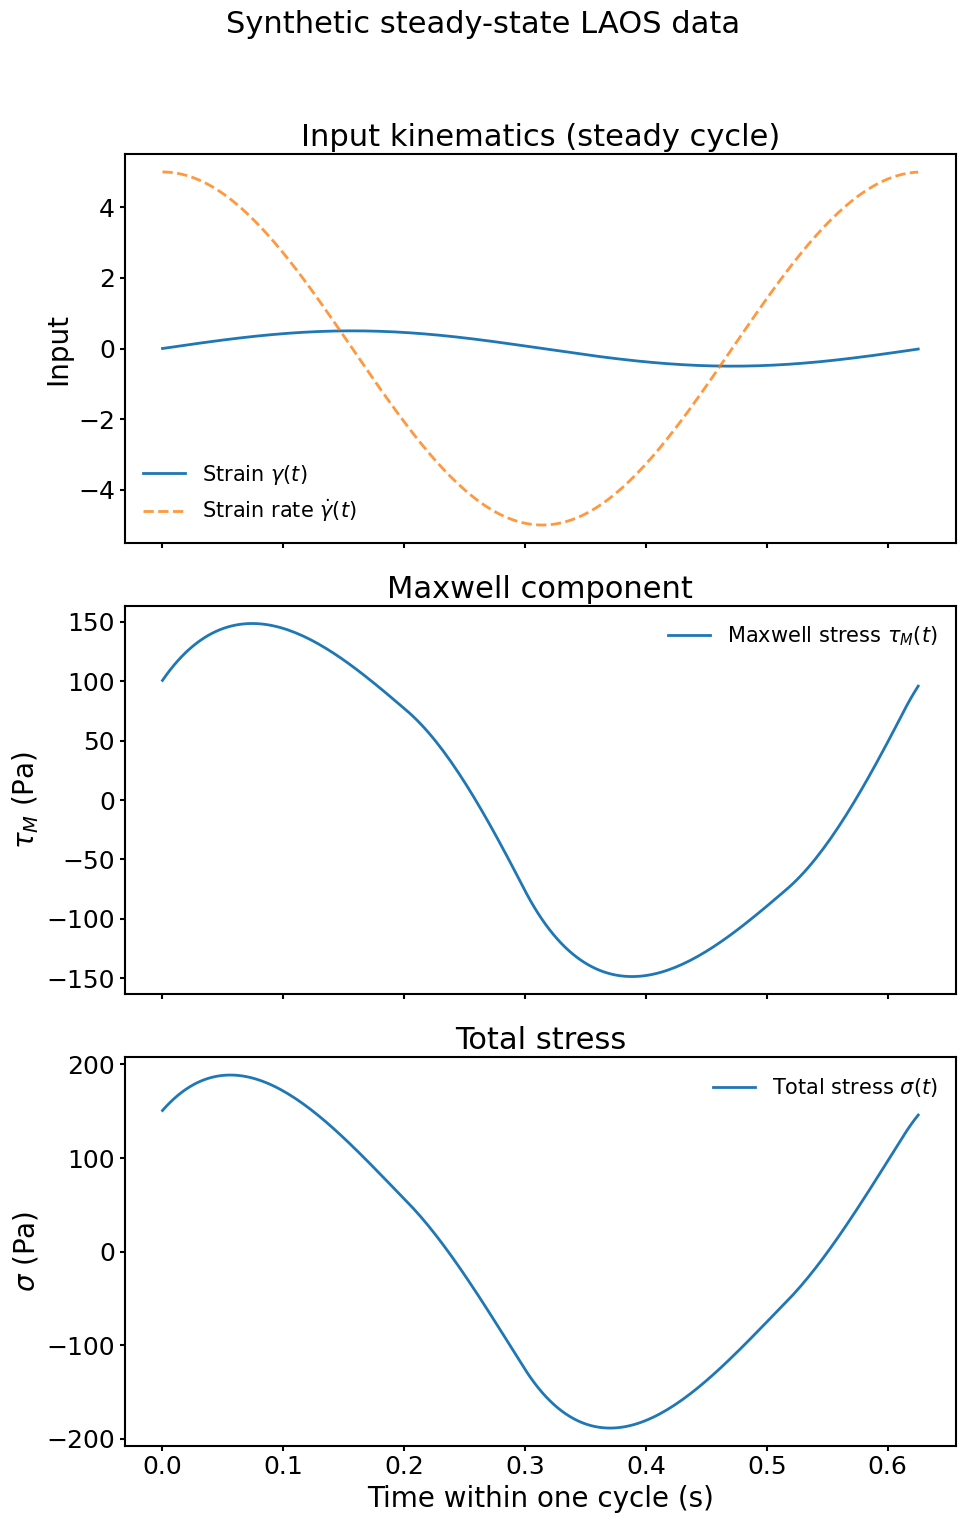

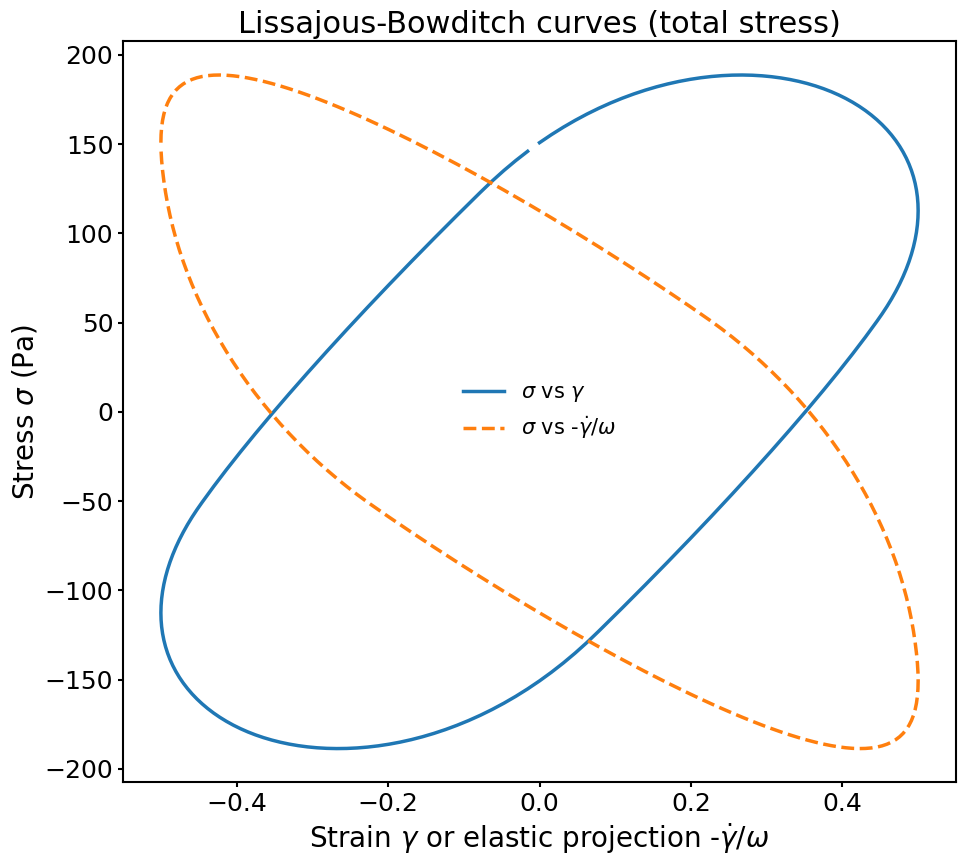


Starting PINN training for steady-cycle LAOS data...
Ep     0/10000 | LR=5.00e-05 | L=6.935e-01 | Data=4.79e-01 | Phys=3.57e-01 | lambda_s=0.100 | tau_0_s=0.10 | eta_p_s=0.100 | eta_s=0.100
Ep   500/10000 | LR=4.99e-04 | L=3.286e-02 | Data=2.26e-02 | Phys=1.71e-02 | lambda_s=0.121 | tau_0_s=0.30 | eta_p_s=0.322 | eta_s=0.255
Ep  1000/10000 | LR=4.92e-04 | L=5.578e-03 | Data=3.03e-03 | Phys=4.24e-03 | lambda_s=0.129 | tau_0_s=0.39 | eta_p_s=0.390 | eta_s=0.287
Ep  1500/10000 | LR=4.79e-04 | L=1.555e-03 | Data=5.73e-04 | Phys=1.64e-03 | lambda_s=0.131 | tau_0_s=0.43 | eta_p_s=0.412 | eta_s=0.283
Ep  2000/10000 | LR=4.60e-04 | L=5.602e-04 | Data=1.45e-04 | Phys=6.93e-04 | lambda_s=0.131 | tau_0_s=0.44 | eta_p_s=0.424 | eta_s=0.279
Ep  2500/10000 | LR=4.35e-04 | L=2.812e-04 | Data=6.13e-05 | Phys=3.66e-04 | lambda_s=0.133 | tau_0_s=0.44 | eta_p_s=0.432 | eta_s=0.277
Ep  3000/10000 | LR=4.06e-04 | L=3.095e-04 | Data=3.91e-05 | Phys=4.51e-04 | lambda_s=0.134 | tau_0_s=0.44 | eta_p_s=0.437 |

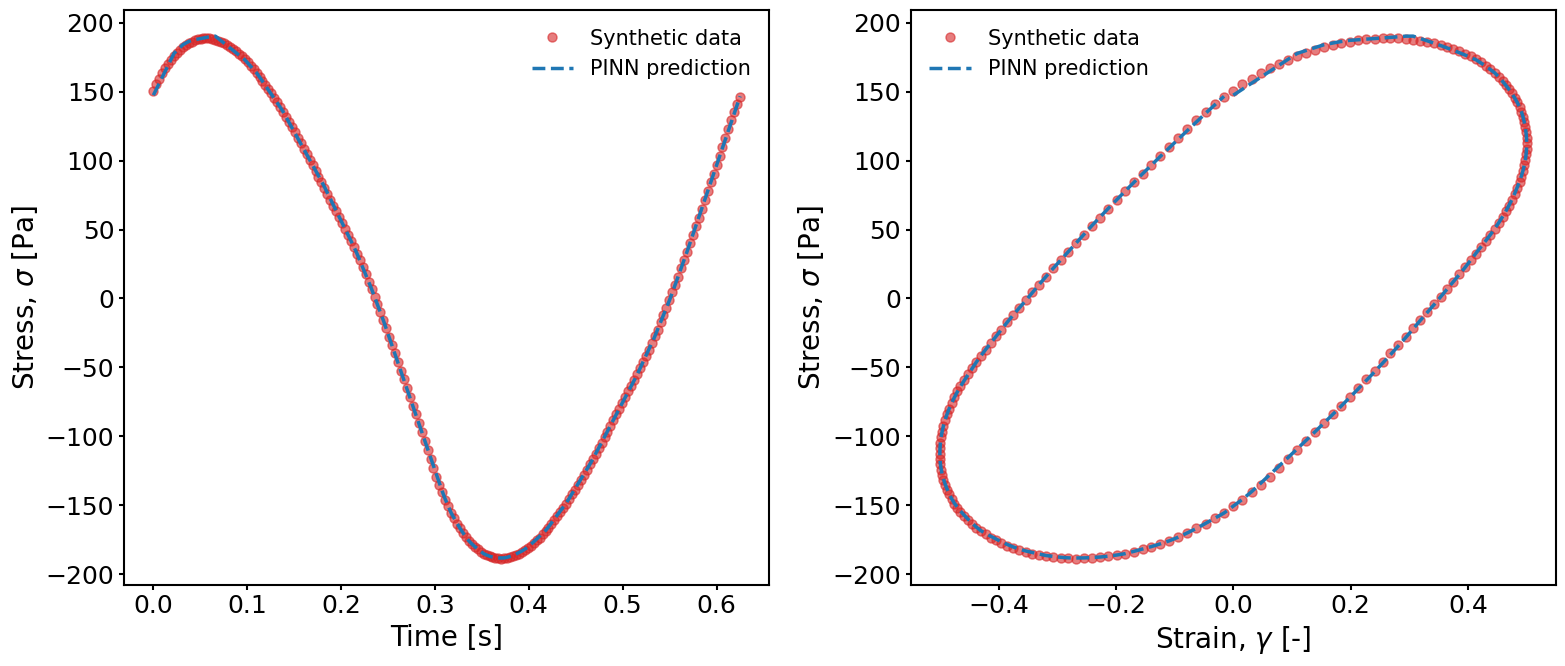

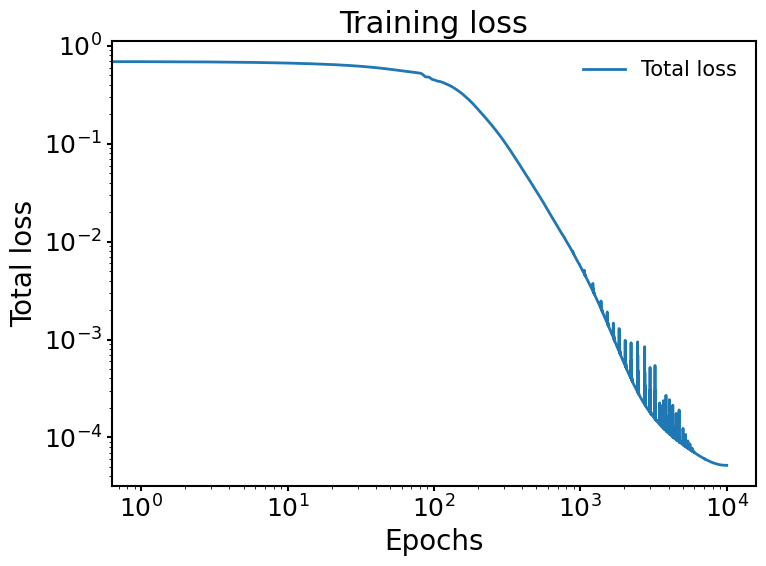


Displaying parameter evolution plots...


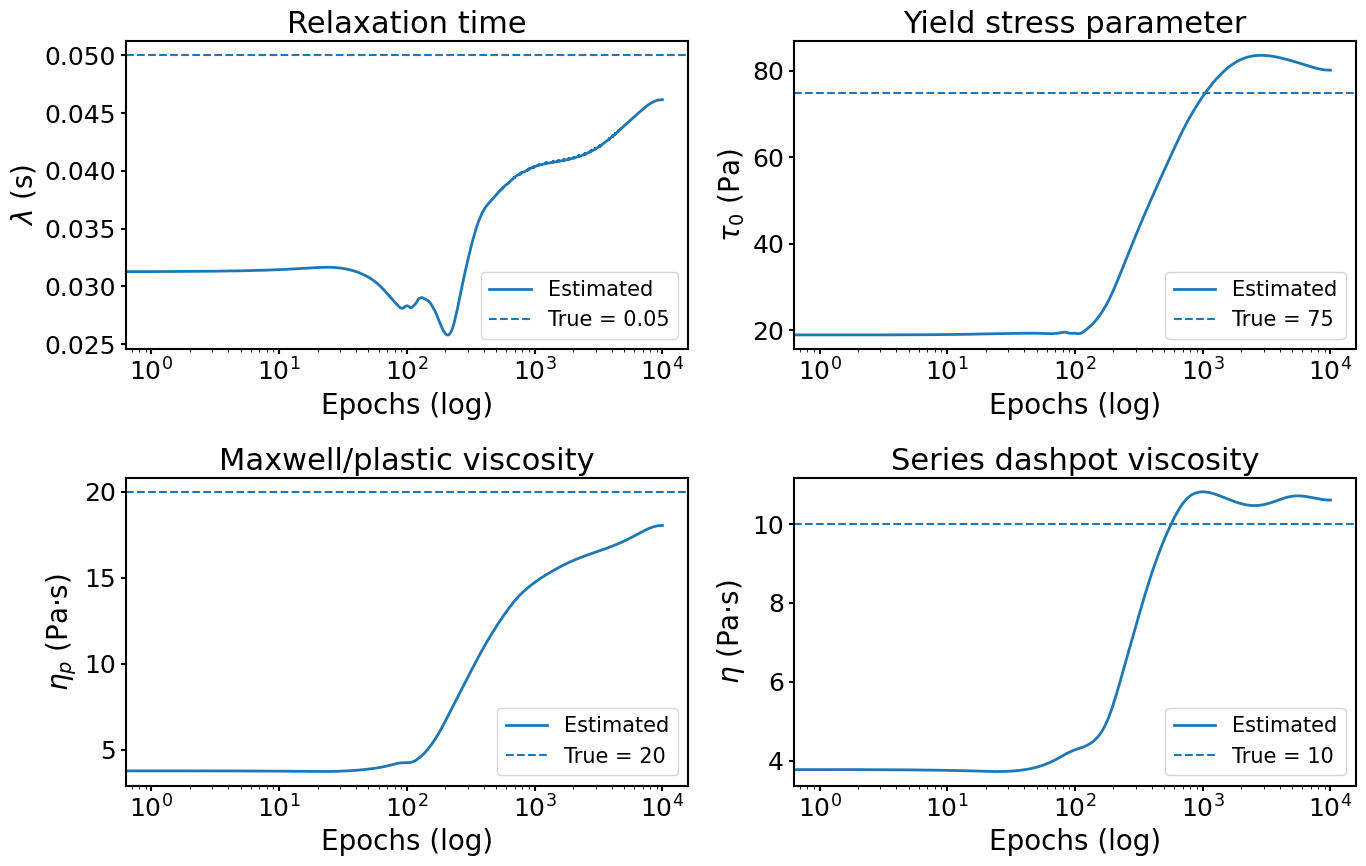


All visualizations complete.


In [8]:

def main():
    set_plot_style()

    # ----------------------------
    # Synthetic experiment params
    # ----------------------------
    amp = 0.5
    omega = 10.0
    alpha = 0.6

    lambda_exp, tau_0_exp, eta_p_exp, eta_exp = 0.05, 75.0, 20.0, 10.0

    t, strain, strain_rate, tau_M, sigma = generate_steady_cycle(
        amp, omega, lambda_exp, tau_0_exp, eta_p_exp, eta_exp,
        n_cycles_total=6, points_per_cycle=200
    )

    print("Displaying initial synthetic steady-cycle LAOS data plots...")
    plot_initial_data(t, strain, strain_rate, tau_M, sigma, omega)

    # ----------------------------
    # Scaling
    # ----------------------------
    t_tensor = torch.tensor(t, dtype=torch.float32).view(-1, 1)
    strain_tensor = torch.tensor(strain, dtype=torch.float32).view(-1, 1)
    strainrate_tensor = torch.tensor(strain_rate, dtype=torch.float32).view(-1, 1)
    sigma_tensor = torch.tensor(sigma, dtype=torch.float32).view(-1, 1)

    scaler_t = MinMaxScaler(feature_range=(-1, 1))
    scaler_strain = MinMaxScaler(feature_range=(-1, 1))
    scaler_strainrate = MinMaxScaler(feature_range=(-1, 1))
    scaler_sigma = MinMaxScaler(feature_range=(-1, 1))

    t_scaled = torch.tensor(scaler_t.fit_transform(t_tensor), dtype=torch.float32)
    strain_scaled = torch.tensor(scaler_strain.fit_transform(strain_tensor), dtype=torch.float32)
    strainrate_scaled = torch.tensor(scaler_strainrate.fit_transform(strainrate_tensor), dtype=torch.float32)
    sigma_scaled = torch.tensor(scaler_sigma.fit_transform(sigma_tensor), dtype=torch.float32)

    dt_scaled = t_scaled[1, 0] - t_scaled[0, 0]

    # ----------------------------
    # Train
    # ----------------------------
    model = PINN()
    optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=5e-5)

    num_epochs = 10000
    loss_threshold = 1e-6
    loss_values = []
    param_history = []

    print("\nStarting PINN training for steady-cycle LAOS data...")
    for epoch in range(num_epochs):
        lr = warmup_then_cosine_lr(
            epoch, num_epochs,
            warmup_epochs=200,
            initial_lr=5e-5,
            max_lr=5e-4,
            min_lr=1e-6,
        )
        optimizer.param_groups[0]["lr"] = lr

        model.train()
        optimizer.zero_grad()

        sigma_pred_scaled = model(t_scaled)
        lam_s, eta_p_s, eta_s, tau_0_s = model.get_parameters()

        total_loss, data_l, phys_l = loss_function(
            sigma_pred_scaled,
            sigma_scaled,
            lam_s,
            tau_0_s,
            eta_p_s,
            eta_s,
            strainrate_scaled,
            dt_scaled,
            alpha=alpha,
        )

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        loss_values.append(total_loss.item())
        param_history.append([lam_s.item(), tau_0_s.item(), eta_p_s.item(), eta_s.item(), total_loss.item()])

        if epoch % 500 == 0 or epoch == num_epochs - 1:
            print(
                f"Ep {epoch:5d}/{num_epochs} | LR={lr:.2e} | L={total_loss.item():.3e} "
                f"| Data={data_l.item():.2e} | Phys={phys_l.item():.2e} "
                f"| lambda_s={lam_s.item():.3f} | tau_0_s={tau_0_s.item():.2f} "
                f"| eta_p_s={eta_p_s.item():.3f} | eta_s={eta_s.item():.3f}"
            )

        if total_loss.item() < loss_threshold:
            print(f"Early stop at epoch {epoch} (loss={total_loss.item():.3e})")
            break

    print("Training finished.")

    # ----------------------------
    # Parameter unscaling
    # ----------------------------
    model.eval()
    with torch.no_grad():
        sigma_pred_final_scaled = model(t_scaled)
        lam_s_final, eta_p_s_final, eta_s_final, tau_0_s_final = model.get_parameters()

    half_time = 0.5 * (scaler_t.data_max_[0] - scaler_t.data_min_[0])
    half_sigma = 0.5 * (scaler_sigma.data_max_[0] - scaler_sigma.data_min_[0])
    half_sr = 0.5 * (scaler_strainrate.data_max_[0] - scaler_strainrate.data_min_[0])

    if abs(half_sr) < 1e-9:
        print("Warning: half_sr is ~0. Using epsilon for unscaling viscosity terms.")
        half_sr_safe = 1e-6
    else:
        half_sr_safe = half_sr

    lambda_rec = lam_s_final.item() * half_time
    tau_0_rec = tau_0_s_final.item() * half_sigma
    eta_rec = eta_s_final.item() * (half_sigma / half_sr_safe)
    eta_p_rec = eta_p_s_final.item() * (half_sigma / half_sr_safe)

    print("\n--- Parameter Recovery ---")
    print(f"{'Parameter':<12} | {'Original':>12} | {'Recovered':>12} | Units")
    print("-" * 60)

    print(f"{'lambda':<12}  | {lambda_exp:>12.4g} | {lambda_rec:>12.4g} | s")
    print(f"{'tau_0':<12}  | {tau_0_exp:>12.4g} | {tau_0_rec:>12.4g} | Pa")
    print(f"{'eta':<12}  | {eta_exp:>12.4g} | {eta_rec:>12.4g} | Pa·s")
    print(f"{'eta_p':<12}  | {eta_p_exp:>12.4g} | {eta_p_rec:>12.4g} | Pa·s")

    if len(loss_values) > 0:
        print(f"\nFinal Total Loss = {loss_values[-1]:.3e}")


    sigma_pred_final = scaler_sigma.inverse_transform(sigma_pred_final_scaled.cpu().numpy())

    # ----------------------------
    # Plots
    # ----------------------------
    print("\nDisplaying final results plots...")
    plot_final_results(t, sigma, sigma_pred_final, loss_values, strain)

    print("\nDisplaying parameter evolution plots...")
    plot_parameter_evolution(
        param_history,
        half_time,
        half_sigma,
        half_sr_safe,
        lam_true=lambda_exp,
        tau_0_true=tau_0_exp,
        eta_p_true=eta_p_exp,
        eta_true=eta_exp,
    )

    print("\nAll visualizations complete.")


if __name__ == "__main__":
    main()